# 03. Model Evaluation

추가 모델 비교, 최종 모델 선정, 입력 시간 비교,
Stratified 성능 평가, 시간순서 추가 검증, SHAP 분석을 수행한다.


## 1. 라이브러리 불러오기


In [1]:
import time
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from pathlib import Path

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


## 2. 추가 모델 비교

### 2-1. 20초 비교 데이터 준비


In [2]:
# 특징 데이터 불러오기
processed_dir = Path('../data/processed')

features_10s = pd.read_parquet(processed_dir / 'features_10s.parquet')
features_20s = pd.read_parquet(processed_dir / 'features_20s.parquet')
features_30s = pd.read_parquet(processed_dir / 'features_30s.parquet')
features_60s = pd.read_parquet(processed_dir / 'features_60s.parquet')

# 정답 데이터 불러오기
profile_path = Path('../data/raw/uci_hydraulic/extracted/profile.txt')
profile = pd.read_csv(profile_path, sep=r'\s+', header=None)
profile.columns = ['cooler', 'valve', 'pump', 'accumulator', 'stable_flag']
profile.insert(0, 'cycle_id', range(1, len(profile) + 1))

component_order = ['cooler', 'valve', 'pump', 'accumulator']

# 시간순서 추가 검증용 기본 분할
train_ids = range(1, 1544)
val_ids = range(1544, 1875)
test_ids = range(1875, 2206)

train_id_set = set(train_ids)
val_id_set = set(val_ids)
test_id_set = set(test_ids)

# 속도 비교 셀에서 사용하는 부품별 정답 변수
y_train_cooler = profile[profile['cycle_id'].isin(train_ids)]['cooler']
y_val_cooler = profile[profile['cycle_id'].isin(val_ids)]['cooler']
y_train_valve = profile[profile['cycle_id'].isin(train_ids)]['valve']
y_val_valve = profile[profile['cycle_id'].isin(val_ids)]['valve']
y_train_pump = profile[profile['cycle_id'].isin(train_ids)]['pump']
y_val_pump = profile[profile['cycle_id'].isin(val_ids)]['pump']
y_train_accumulator = profile[profile['cycle_id'].isin(train_ids)]['accumulator']
y_val_accumulator = profile[profile['cycle_id'].isin(val_ids)]['accumulator']

print('데이터 준비 완료')
print('10초:', features_10s.shape)
print('20초:', features_20s.shape)
print('30초:', features_30s.shape)
print('60초:', features_60s.shape)
print('profile:', profile.shape)

# 20초 특징 데이터
features_20s_compare = features_20s.copy()

# 최종 Test를 제외한 개발 데이터
dev_20s = features_20s_compare[
    features_20s_compare["cycle_id"].between(1, 1874)
].copy()

print("20초 개발 데이터 크기:", dev_20s.shape)

데이터 준비 완료
10초: (2205, 120)
20초: (2205, 120)
30초: (2205, 120)
60초: (2205, 120)
profile: (2205, 6)
20초 개발 데이터 크기: (1874, 120)


In [3]:
# 모델별 공정한 성능 비교를 위해 모든 모델이 동일한 Train / Validation cycle_id를 사용하도록 분할 결과 고정

stratified_split_ids = {}

for component in component_order:

    y_dev = profile[
        profile["cycle_id"].between(1, 1874)
    ][["cycle_id", component]].copy()

    train_ids_s, val_ids_s = train_test_split(
        y_dev["cycle_id"],
        test_size=331,
        random_state=42,
        stratify=y_dev[component]
    )

    stratified_split_ids[component] = {
        "train": set(train_ids_s),
        "val": set(val_ids_s)
    }

    print(
        component,
        "Train:", len(train_ids_s),
        "| Validation:", len(val_ids_s)
    )

cooler Train: 1543 | Validation: 331
valve Train: 1543 | Validation: 331
pump Train: 1543 | Validation: 331
accumulator Train: 1543 | Validation: 331


### 2-2. RandomForest 20초 모델

In [4]:
rf_20s_compare_models = {}
rf_20s_compare_results = []

for component in component_order:

    # 2-1에서 고정한 Train / Validation cycle_id
    train_ids_s = stratified_split_ids[component]["train"]
    val_ids_s = stratified_split_ids[component]["val"]

    # 20초 특징 데이터 분리
    train_df = features_20s_compare[
        features_20s_compare["cycle_id"].isin(train_ids_s)
    ].sort_values("cycle_id")

    val_df = features_20s_compare[
        features_20s_compare["cycle_id"].isin(val_ids_s)
    ].sort_values("cycle_id")

    # 입력 특징 X
    X_train_20 = train_df.drop(columns=["cycle_id"])
    X_val_20 = val_df.drop(columns=["cycle_id"])

    # 정답 y
    y_train_20 = (
        profile[
            profile["cycle_id"].isin(train_ids_s)
        ]
        .sort_values("cycle_id")[component]
    )

    y_val_20 = (
        profile[
            profile["cycle_id"].isin(val_ids_s)
        ]
        .sort_values("cycle_id")[component]
    )

    # RandomForest 모델 생성
    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    # 학습
    model.fit(X_train_20, y_train_20)

    # 예측
    pred = model.predict(X_val_20)

    # 모델 저장
    rf_20s_compare_models[component] = model

    # 평가 결과 저장
    rf_20s_compare_results.append({
        "component": component,
        "accuracy": accuracy_score(y_val_20, pred),
        "macro_f1": f1_score(
            y_val_20,
            pred,
            average="macro"
        )
    })

rf_20s_compare_results = pd.DataFrame(
    rf_20s_compare_results
)

display(rf_20s_compare_results)


,component,accuracy,macro_f1
0,cooler,1.000000,1.000000
1,valve,0.993958,0.993694
2,pump,0.993958,0.993551
3,accumulator,0.984894,0.980269


### 2-3. LightGBM 20초 모델

In [5]:
lgb_20s_compare_models = {}
lgb_20s_compare_results = []

for component in component_order:

    # 2-1에서 고정한 Train / Validation cycle_id
    train_ids_s = stratified_split_ids[component]["train"]
    val_ids_s = stratified_split_ids[component]["val"]

    # 20초 특징 데이터 분리
    train_df = features_20s_compare[
        features_20s_compare["cycle_id"].isin(train_ids_s)
    ].sort_values("cycle_id")

    val_df = features_20s_compare[
        features_20s_compare["cycle_id"].isin(val_ids_s)
    ].sort_values("cycle_id")

    # 입력 특징 X
    X_train_20 = train_df.drop(columns=["cycle_id"])
    X_val_20 = val_df.drop(columns=["cycle_id"])

    # 정답 y
    y_train_20 = (
        profile[
            profile["cycle_id"].isin(train_ids_s)
        ]
        .sort_values("cycle_id")[component]
    )

    y_val_20 = (
        profile[
            profile["cycle_id"].isin(val_ids_s)
        ]
        .sort_values("cycle_id")[component]
    )

    # LightGBM 모델
    model = LGBMClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    model.fit(X_train_20, y_train_20)

    pred = model.predict(X_val_20)

    lgb_20s_compare_models[component] = model

    lgb_20s_compare_results.append({
        "component": component,
        "accuracy": accuracy_score(y_val_20, pred),
        "macro_f1": f1_score(
            y_val_20,
            pred,
            average="macro"
        )
    })

lgb_20s_compare_results = pd.DataFrame(
    lgb_20s_compare_results
)

display(lgb_20s_compare_results)


,component,accuracy,macro_f1
0,cooler,1.000000,1.000000
1,valve,0.996979,0.995098
2,pump,0.993958,0.993551
3,accumulator,0.990937,0.987205


### 2-4. ExtraTrees 20초 모델

In [6]:
extra_20s_compare_models = {}
extra_20s_compare_results = []

for component in component_order:

    train_ids_s = stratified_split_ids[component]["train"]
    val_ids_s = stratified_split_ids[component]["val"]

    # 20초 특징 데이터
    train_df = features_20s_compare[
        features_20s_compare["cycle_id"].isin(train_ids_s)
    ].sort_values("cycle_id")

    val_df = features_20s_compare[
        features_20s_compare["cycle_id"].isin(val_ids_s)
    ].sort_values("cycle_id")

    X_train_20 = train_df.drop(columns=["cycle_id"])
    X_val_20 = val_df.drop(columns=["cycle_id"])

    # 정답 데이터
    y_train_20 = (
        profile[
            profile["cycle_id"].isin(train_ids_s)
        ]
        .sort_values("cycle_id")[component]
    )

    y_val_20 = (
        profile[
            profile["cycle_id"].isin(val_ids_s)
        ]
        .sort_values("cycle_id")[component]
    )

    # ExtraTrees 모델
    model = ExtraTreesClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_20, y_train_20)

    pred = model.predict(X_val_20)

    extra_20s_compare_models[component] = model

    extra_20s_compare_results.append({
        "component": component,
        "accuracy": accuracy_score(y_val_20, pred),
        "macro_f1": f1_score(
            y_val_20,
            pred,
            average="macro"
        )
    })

extra_20s_compare_results = pd.DataFrame(
    extra_20s_compare_results
)

display(extra_20s_compare_results)

,component,accuracy,macro_f1
0,cooler,1.000000,1.000000
1,valve,1.000000,1.000000
2,pump,0.996979,0.996789
3,accumulator,0.993958,0.991444


### 2-5. XGBoost 20초 모델

In [7]:
xgb_20s_compare_models = {}
xgb_20s_label_encoders = {}
xgb_20s_compare_results = []

for component in component_order:

    train_ids_s = stratified_split_ids[component]["train"]
    val_ids_s = stratified_split_ids[component]["val"]

    # 20초 특징 데이터
    train_df = features_20s_compare[
        features_20s_compare["cycle_id"].isin(train_ids_s)
    ].sort_values("cycle_id")

    val_df = features_20s_compare[
        features_20s_compare["cycle_id"].isin(val_ids_s)
    ].sort_values("cycle_id")

    X_train_20 = train_df.drop(columns=["cycle_id"])
    X_val_20 = val_df.drop(columns=["cycle_id"])

    # 원래 정답
    y_train_original = (
        profile[
            profile["cycle_id"].isin(train_ids_s)
        ]
        .sort_values("cycle_id")[component]
    )

    y_val_original = (
        profile[
            profile["cycle_id"].isin(val_ids_s)
        ]
        .sort_values("cycle_id")[component]
    )

    # XGBoost가 클래스 번호를 0부터 연속된 값으로 사용하도록 원래 상태 코드를 변환
    encoder = LabelEncoder()

    y_train_encoded = encoder.fit_transform(
        y_train_original
    )

    y_val_encoded = encoder.transform(
        y_val_original
    )

    # XGBoost 모델
    model = XGBClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss"
    )

    model.fit(
        X_train_20,
        y_train_encoded
    )

    # 예측
    pred_encoded = model.predict(X_val_20)

    # 평가할 때 실제 상태 코드와 비교할 수 있도록 예측값을 원래 라벨로 복원
    pred_original = encoder.inverse_transform(
        pred_encoded.astype(int)
    )

    # 모델과 라벨 변환기 저장
    xgb_20s_compare_models[component] = model
    xgb_20s_label_encoders[component] = encoder

    # 평가
    xgb_20s_compare_results.append({
        "component": component,
        "accuracy": accuracy_score(
            y_val_original,
            pred_original
        ),
        "macro_f1": f1_score(
            y_val_original,
            pred_original,
            average="macro"
        )
    })

xgb_20s_compare_results = pd.DataFrame(
    xgb_20s_compare_results
)

display(xgb_20s_compare_results)

,component,accuracy,macro_f1
0,cooler,1.000000,1.000000
1,valve,0.993958,0.990146
2,pump,0.990937,0.988855
3,accumulator,0.981873,0.977962


### 2-6. 20초 모델 성능 비교

In [8]:
# 각 모델의 부품별 평가 결과에서 평균 성능을 자동 계산
model_result_tables = {
    "RandomForest": rf_20s_compare_results,
    "LightGBM": lgb_20s_compare_results,
    "ExtraTrees": extra_20s_compare_results,
    "XGBoost": xgb_20s_compare_results
}

model_compare_rows = []

for model_name, result_df in model_result_tables.items():
    model_compare_rows.append({
        "model": model_name,
        "accuracy": result_df["accuracy"].mean(),
        "macro_f1": result_df["macro_f1"].mean()
    })

model_compare = pd.DataFrame(model_compare_rows)

# Macro F1 높은 순서로 정렬
model_compare = model_compare.sort_values(
    "macro_f1",
    ascending=False
).reset_index(drop=True)

display(model_compare)


,model,accuracy,macro_f1
0,ExtraTrees,0.997734,0.997058
1,LightGBM,0.995468,0.993963
2,RandomForest,0.993202,0.991878
3,XGBoost,0.991692,0.989241


### 2-7. 모델 학습·예측 속도 비교

In [9]:
# 비교할 모델 생성 함수
def get_model(model_name):
    if model_name == "RandomForest":
        return RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )

    if model_name == "LightGBM":
        return LGBMClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        )

    if model_name == "ExtraTrees":
        return ExtraTreesClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )

    if model_name == "XGBoost":
        return XGBClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1,
            eval_metric="mlogloss"
        )

    raise ValueError(f"지원하지 않는 모델: {model_name}")


model_names = [
    "RandomForest",
    "LightGBM",
    "ExtraTrees",
    "XGBoost"
]

speed_results = []

for model_name in model_names:

    total_train_time = 0.0
    total_predict_time = 0.0

    for component in component_order:

        # 2-1에서 고정한 해당 부품의 Stratified cycle_id
        train_ids_s = stratified_split_ids[component]["train"]
        val_ids_s = stratified_split_ids[component]["val"]

        # 해당 부품의 cycle_id에 맞는 20초 특징 데이터
        train_df = (
            features_20s_compare[
                features_20s_compare["cycle_id"].isin(train_ids_s)
            ]
            .sort_values("cycle_id")
        )

        val_df = (
            features_20s_compare[
                features_20s_compare["cycle_id"].isin(val_ids_s)
            ]
            .sort_values("cycle_id")
        )

        X_train_speed = train_df.drop(columns=["cycle_id"])
        X_val_speed = val_df.drop(columns=["cycle_id"])

        # X와 동일한 cycle_id 순서의 정답
        y_train_speed = (
            profile[
                profile["cycle_id"].isin(train_ids_s)
            ]
            .sort_values("cycle_id")[component]
        )

        y_val_speed = (
            profile[
                profile["cycle_id"].isin(val_ids_s)
            ]
            .sort_values("cycle_id")[component]
        )

        # 모든 모델이 같은 형태의 0부터 시작하는 숫자 라벨을 사용
        encoder = LabelEncoder()
        y_train_encoded = encoder.fit_transform(y_train_speed)
        y_val_encoded = encoder.transform(y_val_speed)

        # 부품마다 새 모델을 생성하여 학습/예측 시간 측정
        model = get_model(model_name)

        start = time.perf_counter()
        model.fit(
            X_train_speed,
            y_train_encoded
        )
        total_train_time += time.perf_counter() - start

        start = time.perf_counter()
        model.predict(X_val_speed)
        total_predict_time += time.perf_counter() - start

    speed_results.append({
        "model": model_name,
        "train_time_sec": total_train_time,
        "predict_time_sec": total_predict_time
    })


speed_compare = pd.DataFrame(speed_results)

# 예측 속도가 빠른 순서
speed_compare = speed_compare.sort_values(
    "predict_time_sec"
).reset_index(drop=True)

display(speed_compare)


,model,train_time_sec,predict_time_sec
0,LightGBM,5.673145,0.036918
1,XGBoost,5.324690,0.079955
2,ExtraTrees,1.196373,0.219101
3,RandomForest,2.439661,0.311483


### 2-8. 최종 모델 선정

In [10]:
# 성능 + 속도 비교 결과 합치기
final_model_compare = model_compare.merge(
    speed_compare,
    on="model"
)

# Macro F1 높은 순으로 정렬
final_model_compare = final_model_compare.sort_values(
    "macro_f1",
    ascending=False
).reset_index(drop=True)

display(final_model_compare)

,model,accuracy,macro_f1,train_time_sec,predict_time_sec
0,ExtraTrees,0.997734,0.997058,1.196373,0.219101
1,LightGBM,0.995468,0.993963,5.673145,0.036918
2,RandomForest,0.993202,0.991878,2.439661,0.311483
3,XGBoost,0.991692,0.989241,5.324690,0.079955


#### 최종 모델: LightGBM

20초 입력 데이터를 기준으로 RandomForest, LightGBM, ExtraTrees, XGBoost의
분류 성능과 처리 속도를 비교하였다.

- ExtraTrees가 Accuracy와 Macro F1에서 가장 높은 성능을 보였다.
- LightGBM은 ExtraTrees보다 성능이 소폭 낮았지만 Macro F1 0.993963으로 매우 높은 성능을 유지하였다.
- 예측 시간은 LightGBM이 0.040초로 네 모델 중 가장 빨랐다.
- 본 프로젝트는 Kafka를 통해 센서 데이터를 받아 반복적으로 상태를 예측하는 실시간 시스템을 목표로 하므로,
  학습 속도보다 실제 서비스 단계의 예측 속도가 중요하다.

따라서 높은 분류 성능을 유지하면서 가장 빠른 예측 속도를 보인
LightGBM을 최종 모델로 선정하였다.

## 3. LightGBM 입력 시간별 성능 비교

### 3-1. 10초 / 20초 / 30초 / 60초 성능 비교

In [11]:
# 시간별 전체 특징 데이터
window_features = {
    "10초": features_10s,
    "20초": features_20s_compare,
    "30초": features_30s,
    "60초": features_60s
}

components = [
    "cooler",
    "valve",
    "pump",
    "accumulator"
]

window_results = []


for window_name, features in window_features.items():

    feature_cols = [
        col for col in features.columns
        if col != "cycle_id"
    ]

    for component in components:

        # 해당 부품에 고정된 Stratified cycle_id 사용
        train_ids_s = stratified_split_ids[component]["train"]
        val_ids_s = stratified_split_ids[component]["val"]

        # 시간 구간별 특징 데이터 분리
        train_part = (
            features[
                features["cycle_id"].isin(train_ids_s)
            ]
            .sort_values("cycle_id")
        )

        val_part = (
            features[
                features["cycle_id"].isin(val_ids_s)
            ]
            .sort_values("cycle_id")
        )

        X_tr = train_part[feature_cols]
        X_va = val_part[feature_cols]

        # X와 동일한 cycle_id 순서의 정답
        y_tr = (
            profile[
                profile["cycle_id"].isin(train_ids_s)
            ]
            .sort_values("cycle_id")[component]
        )

        y_va = (
            profile[
                profile["cycle_id"].isin(val_ids_s)
            ]
            .sort_values("cycle_id")[component]
        )

        encoder = LabelEncoder()

        y_tr_encoded = encoder.fit_transform(y_tr)
        y_va_encoded = encoder.transform(y_va)

        model = LGBMClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        )

        model.fit(
            X_tr,
            y_tr_encoded
        )

        pred = model.predict(X_va)

        window_results.append({
            "window": window_name,
            "component": component,
            "accuracy": accuracy_score(
                y_va_encoded,
                pred
            ),
            "macro_f1": f1_score(
                y_va_encoded,
                pred,
                average="macro"
            )
        })


window_compare = pd.DataFrame(window_results)

display(window_compare)


,window,component,accuracy,macro_f1
0,10초,cooler,1.000000,1.000000
1,10초,valve,1.000000,1.000000
2,10초,pump,1.000000,1.000000
3,10초,accumulator,0.984894,0.980189
4,20초,cooler,1.000000,1.000000
5,20초,valve,0.996979,0.995098
6,20초,pump,0.993958,0.993551
7,20초,accumulator,0.990937,0.987205
8,30초,cooler,1.000000,1.000000
9,30초,valve,0.996979,0.996869


In [12]:
# 입력 시간별 평균 성능
window_summary = (
    window_compare
    .groupby("window")[["accuracy", "macro_f1"]]
    .mean()
    .sort_values(
        "macro_f1",
        ascending=False
    )
)

display(window_summary)

,accuracy,macro_f1
window,,
10초,0.996224,0.995047
30초,0.995468,0.994683
20초,0.995468,0.993963
60초,0.993202,0.992048


### 3-2. 최종 입력 시간 선정

In [13]:
# 20초와 60초 Macro F1 비교
f1_20 = window_summary.loc["20초", "macro_f1"]
f1_60 = window_summary.loc["60초", "macro_f1"]

performance_ratio = f1_20 / f1_60 * 100

print(f"20초 Macro F1 : {f1_20:.6f}")
print(f"60초 Macro F1 : {f1_60:.6f}")
print(f"60초 대비 20초 성능 유지율 : {performance_ratio:.2f}%")

if performance_ratio >= 95:
    print("→ 20초 입력을 최종 입력 시간으로 선정")
else:
    print("→ 20초 입력은 95% 기준을 충족하지 못함")

20초 Macro F1 : 0.993963
60초 Macro F1 : 0.992048
60초 대비 20초 성능 유지율 : 100.19%
→ 20초 입력을 최종 입력 시간으로 선정


#### 최종 입력 시간: 20초

위 셀에서 동일한 Stratified 분할 기준으로 10초, 20초, 30초, 60초 입력의 평균 Accuracy와 Macro F1을 비교한다.

20초 입력은 60초 전체 데이터를 기다리지 않고 운전 초기에 상태를 판별하기 위한 후보이며, 위에서 계산한 `60초 대비 20초 성능 유지율`이 프로젝트 기준인 95% 이상인지 확인한 뒤 최종 입력 시간으로 사용한다.

최종 Test 데이터는 이 단계의 모델·입력 시간 선정에 사용하지 않는다.


## 4. Stratified Validation 기준 모델 성능

### 4-1. LightGBM 20초 부품별 Validation 성능


In [14]:
# 최종 선정 조건: LightGBM + 20초 + Stratified 분할

final_stratified_result = (
    window_compare[
        window_compare["window"] == "20초"
    ][["component", "accuracy", "macro_f1"]]
    .reset_index(drop=True)
)

display(final_stratified_result)

,component,accuracy,macro_f1
0,cooler,1.000000,1.000000
1,valve,0.996979,0.995098
2,pump,0.993958,0.993551
3,accumulator,0.990937,0.987205


### 4-2. 평균 Validation 성능


In [15]:
final_stratified_accuracy = (
    final_stratified_result["accuracy"].mean()
)

final_stratified_macro_f1 = (
    final_stratified_result["macro_f1"].mean()
)

print(
    f"Stratified 평균 Accuracy : "
    f"{final_stratified_accuracy:.6f}"
)

print(
    f"Stratified 평균 Macro F1 : "
    f"{final_stratified_macro_f1:.6f}"
)

Stratified 평균 Accuracy : 0.995468
Stratified 평균 Macro F1 : 0.993963


#### Stratified Validation 결과

Stratified 분할을 기준으로 선정한 LightGBM 20초 모델의 Validation 성능을 평가한다.

클래스 비율을 학습·검증 데이터에 유사하게 유지하여 모델의 기본적인 분류 성능을 비교하며, 이 결과는 모델 선정과 입력 시간 비교에 사용한다.

최종 일반화 성능은 마지막 단계에서 별도로 보관한 Test 데이터로 한 번 평가한다.


## 5. 시간순서 기반 추가 검증

### 5-1. 시간순서 Validation 성능

In [16]:
components = [
    "cooler",
    "valve",
    "pump",
    "accumulator"
]


# 시간순서 Train / Validation 데이터
time_train = features_20s_compare[
    features_20s_compare["cycle_id"].isin(train_id_set)
].copy()

time_val = features_20s_compare[
    features_20s_compare["cycle_id"].isin(val_id_set)
].copy()


# 정답 연결
time_train = time_train.merge(
    profile[["cycle_id"] + components],
    on="cycle_id",
    how="left"
)

time_val = time_val.merge(
    profile[["cycle_id"] + components],
    on="cycle_id",
    how="left"
)


# 모델 입력 특징
time_feature_cols = [
    col for col in features_20s_compare.columns
    if col != "cycle_id"
]

X_time_train = time_train[time_feature_cols]
X_time_val = time_val[time_feature_cols]


time_val_results = []

for component in components:

    y_tr = time_train[component]
    y_va = time_val[component]

    encoder = LabelEncoder()

    y_tr_encoded = encoder.fit_transform(y_tr)
    y_va_encoded = encoder.transform(y_va)

    model = LGBMClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(
        X_time_train,
        y_tr_encoded
    )

    pred = model.predict(
        X_time_val
    )

    time_val_results.append({
        "component": component,
        "accuracy": accuracy_score(
            y_va_encoded,
            pred
        ),
        "macro_f1": f1_score(
            y_va_encoded,
            pred,
            average="macro"
        )
    })


time_val_compare = pd.DataFrame(
    time_val_results
)

display(time_val_compare)


,component,accuracy,macro_f1
0,cooler,0.996979,0.499244
1,valve,0.561934,0.199143
2,pump,0.933535,0.895817
3,accumulator,0.365559,0.178466


### 5-2. 시간순서 평균 성능

In [17]:
time_accuracy = (
    time_val_compare["accuracy"].mean()
)

time_macro_f1 = (
    time_val_compare["macro_f1"].mean()
)

print(
    f"시간순서 평균 Accuracy : "
    f"{time_accuracy:.6f}"
)

print(
    f"시간순서 평균 Macro F1 : "
    f"{time_macro_f1:.6f}"
)

시간순서 평균 Accuracy : 0.714502
시간순서 평균 Macro F1 : 0.443168


### 5-3. Stratified 분할과 시간순서 분할 비교

In [18]:
split_final_compare = pd.DataFrame({
    "split": [
        "Stratified",
        "Time-order"
    ],
    "accuracy": [
        final_stratified_accuracy,
        time_accuracy
    ],
    "macro_f1": [
        final_stratified_macro_f1,
        time_macro_f1
    ]
})

display(split_final_compare)

,split,accuracy,macro_f1
0,Stratified,0.995468,0.993963
1,Time-order,0.714502,0.443168


#### 분할 방식에 따른 성능 차이

Stratified 분할에서는 클래스 비율을 유사하게 유지하여
높은 분류 성능을 확인하였다.

반면 시간순서 분할에서는 학습 구간과 이후 검증 구간의
데이터 분포 차이로 인해 성능이 감소하였다.

따라서 본 모델은 일반적인 Stratified 환경에서는 높은 성능을 보이지만,
시간적으로 분리된 신규 데이터에서는 분포 변화에 따라
성능이 저하될 가능성이 있음을 확인하였다.

시간순서 검증 결과는 모델의 한계 및 강건성 평가 결과로 별도로 기록한다.

## 6. SHAP 기반 주요 영향 특징 분석

* SHAP는 모델이 왜 이런 예측을 했는지 설명해주는 방법

### 6-1. SHAP 라이브러리 확인

In [19]:
print("SHAP version:", shap.__version__)


SHAP version: 0.49.1


### 6-2. 부품별 SHAP 중요 특징 계산

In [20]:
# 부품별 SHAP 상위 특징 저장
shap_top_features = {}

for component in component_order:

    print(f"\n===== {component.upper()} =====")

    # 앞에서 학습한 20초 LightGBM 모델
    model = lgb_20s_compare_models[component]

    # 해당 부품 Validation cycle_id
    val_ids_s = stratified_split_ids[component]["val"]

    # Validation 특징 데이터
    shap_df = (
        features_20s_compare[
            features_20s_compare["cycle_id"].isin(val_ids_s)
        ]
        .sort_values("cycle_id")
    )

    X_shap = shap_df.drop(columns=["cycle_id"])

    # SHAP 계산
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_shap)

    # SHAP 반환 형태 처리
    if isinstance(shap_values, list):

        mean_abs_shap = np.mean(
            np.stack(
                [np.abs(values) for values in shap_values],
                axis=0
            ),
            axis=(0, 1)
        )

    else:

        shap_array = np.asarray(shap_values)

        # 다중분류
        if shap_array.ndim == 3:
            mean_abs_shap = np.mean(
                np.abs(shap_array),
                axis=(0, 2)
            )

        # 2차원
        else:
            mean_abs_shap = np.mean(
                np.abs(shap_array),
                axis=0
            )

    # 특징별 중요도
    importance_df = pd.DataFrame({
        "feature": X_shap.columns,
        "mean_abs_shap": mean_abs_shap
    })

    importance_df = (
        importance_df
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )

    # TOP 10
    shap_top_features[component] = importance_df.head(10)

    display(shap_top_features[component])



===== COOLER =====


,feature,mean_abs_shap
0,CE_min,2.073752
1,CP_mean,1.212455
2,CE_max,0.667226
3,PS2_max,0.523674
4,TS4_min,0.449567
5,PS1_min,0.434167
6,CE_mean,0.341727
7,CP_max,0.286799
8,FS2_std,0.159988
9,TS1_range,0.157524



===== VALVE =====


,feature,mean_abs_shap
0,PS2_mean,2.344060
1,SE_mean,0.961643
2,SE_std,0.727228
3,FS1_std,0.689108
4,FS1_max,0.596761
5,SE_max,0.494698
6,PS1_mean,0.386753
7,FS1_slope,0.346438
8,SE_rms,0.275063
9,PS2_std,0.181926



===== PUMP =====


,feature,mean_abs_shap
0,FS1_slope,2.582397
1,SE_max,1.007770
2,FS1_mean,0.882329
3,SE_slope,0.709430
4,FS1_rms,0.389468
5,EPS1_min,0.240429
6,FS1_std,0.225950
7,VS1_std,0.192035
8,PS3_rms,0.191937
9,VS1_max,0.188493



===== ACCUMULATOR =====


,feature,mean_abs_shap
0,PS3_std,1.248108
1,SE_slope,0.619915
2,FS2_min,0.538411
3,PS1_slope,0.536208
4,CP_max,0.503560
5,FS1_slope,0.459605
6,FS1_max,0.455635
7,TS1_min,0.441554
8,FS1_std,0.394712
9,TS4_mean,0.369232


### 6-3. 부품별 SHAP 중요 특징 그래프 저장

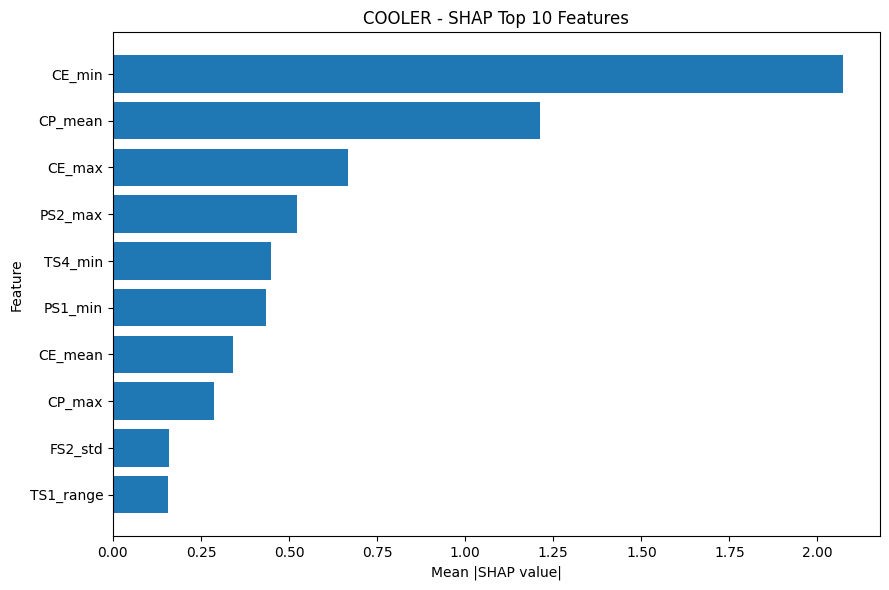

저장 완료: ..\reports\model\shap_cooler_top10.png


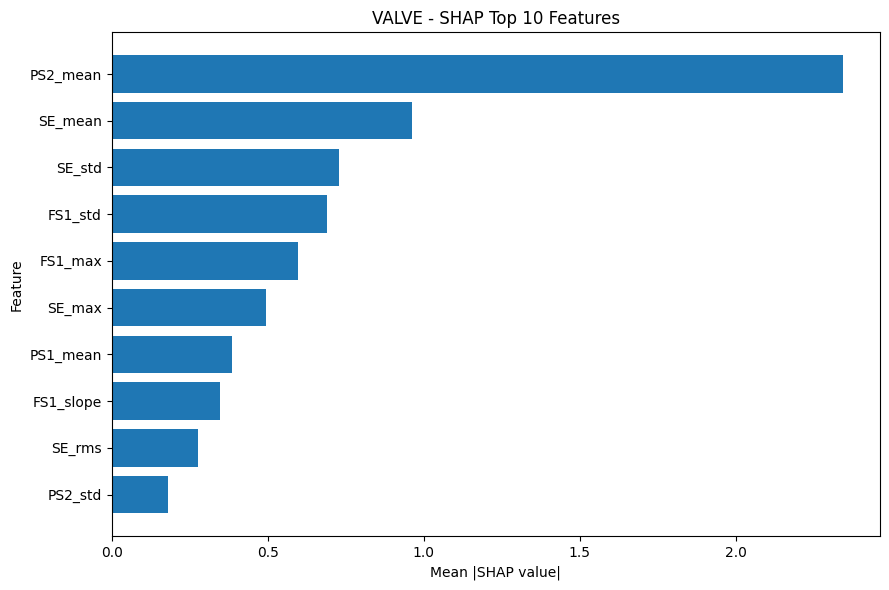

저장 완료: ..\reports\model\shap_valve_top10.png


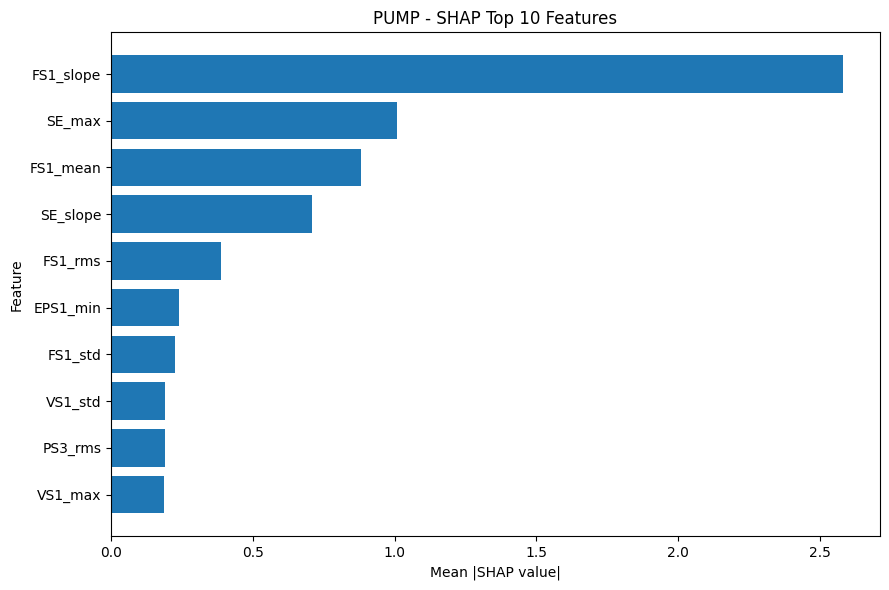

저장 완료: ..\reports\model\shap_pump_top10.png


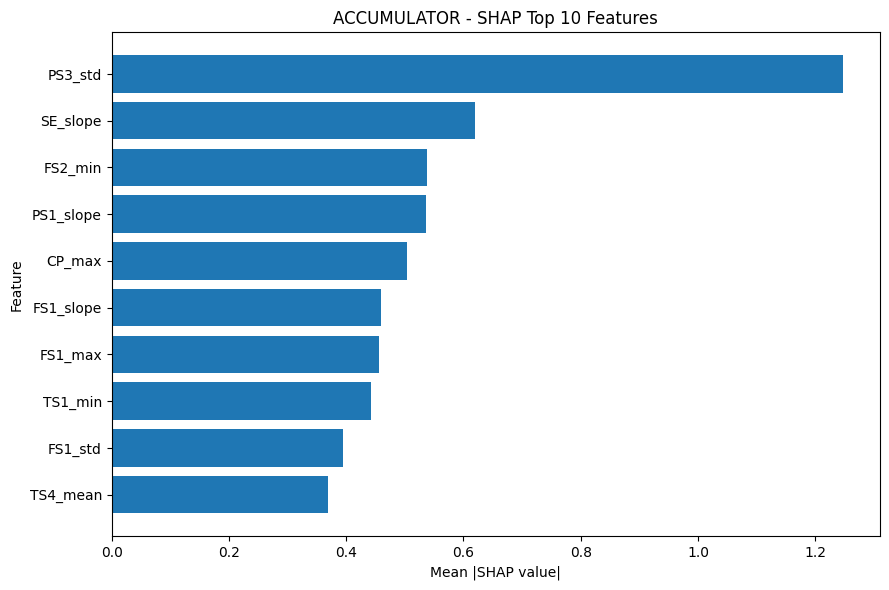

저장 완료: ..\reports\model\shap_accumulator_top10.png


In [21]:
# 저장 폴더 생성
report_model_dir = Path("../reports/model")
report_model_dir.mkdir(parents=True, exist_ok=True)

for component in component_order:

    # TOP 10 특징
    plot_df = shap_top_features[component].copy()

    # barh 그래프에서 높은 값이 위로 오도록 정렬
    plot_df = plot_df.sort_values(
        "mean_abs_shap",
        ascending=True
    )

    plt.figure(figsize=(9, 6))

    plt.barh(
        plot_df["feature"],
        plot_df["mean_abs_shap"]
    )

    plt.title(
        f"{component.upper()} - SHAP Top 10 Features"
    )

    plt.xlabel("Mean |SHAP value|")
    plt.ylabel("Feature")

    plt.tight_layout()

    # 저장 경로
    save_path = (
        report_model_dir
        / f"shap_{component}_top10.png"
    )

    plt.savefig(
        save_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    print("저장 완료:", save_path)


### 6-4. API 전달용 SHAP 결과 생성

In [22]:
# API에서 사용할 SHAP 결과
shap_api_result = {}

for component in component_order:

    top_df = shap_top_features[component]

    shap_api_result[component] = [
        {
            "feature": row["feature"],
            "impact": round(float(row["mean_abs_shap"]), 6)
        }
        for _, row in top_df.iterrows()
    ]

# JSON 형태 확인
print(
    json.dumps(
        shap_api_result,
        ensure_ascii=False,
        indent=2
    )
)


{
  "cooler": [
    {
      "feature": "CE_min",
      "impact": 2.073752
    },
    {
      "feature": "CP_mean",
      "impact": 1.212455
    },
    {
      "feature": "CE_max",
      "impact": 0.667226
    },
    {
      "feature": "PS2_max",
      "impact": 0.523674
    },
    {
      "feature": "TS4_min",
      "impact": 0.449567
    },
    {
      "feature": "PS1_min",
      "impact": 0.434167
    },
    {
      "feature": "CE_mean",
      "impact": 0.341727
    },
    {
      "feature": "CP_max",
      "impact": 0.286799
    },
    {
      "feature": "FS2_std",
      "impact": 0.159988
    },
    {
      "feature": "TS1_range",
      "impact": 0.157524
    }
  ],
  "valve": [
    {
      "feature": "PS2_mean",
      "impact": 2.34406
    },
    {
      "feature": "SE_mean",
      "impact": 0.961643
    },
    {
      "feature": "SE_std",
      "impact": 0.727228
    },
    {
      "feature": "FS1_std",
      "impact": 0.689108
    },
    {
      "feature": "FS1_max",
      "impa

## 7. 최종 모델 학습 및 Test 평가

### 7-1. 최종 LightGBM 20초 모델 학습

In [23]:
# 최종 모델 저장용 딕셔너리
final_models = {}

# Train + Validation 전체 = 개발 데이터
dev_df = (
    features_20s_compare[
        features_20s_compare["cycle_id"].between(1, 1874)
    ]
    .sort_values("cycle_id")
)

X_dev_final = dev_df.drop(columns=["cycle_id"])

print("최종 학습 데이터 크기:", X_dev_final.shape)

for component in component_order:

    # 개발 데이터 정답
    y_dev_final = (
        profile[
            profile["cycle_id"].between(1, 1874)
        ]
        .sort_values("cycle_id")[component]
    )

    # 최종 LightGBM 모델
    model = LGBMClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    # Train + Validation 전체로 최종 학습
    model.fit(
        X_dev_final,
        y_dev_final
    )

    final_models[component] = model

    print(
        f"{component} 최종 모델 학습 완료"
    )



# 축압기 라벨/분포 확인

print("=== 축압기 전체 클래스 ===")
print(sorted(profile["accumulator"].unique()))

print("\n=== 결측값 개수 ===")
print(profile["accumulator"].isna().sum())

print("\n=== 전체 데이터 분포 ===")
print(
    profile["accumulator"]
    .value_counts()
    .sort_index()
)

print("\n=== 개발 데이터 분포 (1~1874) ===")
print(
    profile[
        profile["cycle_id"].between(1, 1874)
    ]["accumulator"]
    .value_counts()
    .sort_index()
)

print("\n=== 최종 Test 분포 (1875~2205) ===")
print(
    profile[
        profile["cycle_id"].between(1875, 2205)
    ]["accumulator"]
    .value_counts()
    .sort_index()
)


# cycle 구간별 축압기 상태 분포 확인

acc_check = profile[
    ["cycle_id", "accumulator"]
].copy()

acc_check["cycle_group"] = (
    (acc_check["cycle_id"] - 1) // 200
) * 200 + 1

acc_distribution = pd.crosstab(
    acc_check["cycle_group"],
    acc_check["accumulator"]
)

display(acc_distribution)

최종 학습 데이터 크기: (1874, 119)
cooler 최종 모델 학습 완료
valve 최종 모델 학습 완료
pump 최종 모델 학습 완료
accumulator 최종 모델 학습 완료
=== 축압기 전체 클래스 ===
[np.int64(90), np.int64(100), np.int64(115), np.int64(130)]

=== 결측값 개수 ===
0

=== 전체 데이터 분포 ===
accumulator
90     808
100    399
115    399
130    599
Name: count, dtype: int64

=== 개발 데이터 분포 (1~1874) ===
accumulator
90     666
100    266
115    343
130    599
Name: count, dtype: int64

=== 최종 Test 분포 (1875~2205) ===
accumulator
90     142
100    133
115     56
Name: count, dtype: int64


accumulator,90,100,115,130
cycle_group,,,,
1,0,0,0,200
201,0,0,67,133
401,1,133,66,0
601,200,0,0,0
801,132,0,0,68
1001,0,2,133,65
1201,69,131,0,0
1401,200,0,0,0
1601,64,0,3,133


### 7-2. 최종 Test 데이터 성능 평가

최종 Test 데이터 크기: (331, 119)

===== COOLER =====
Accuracy : 1.000000
Macro F1 : 1.000000


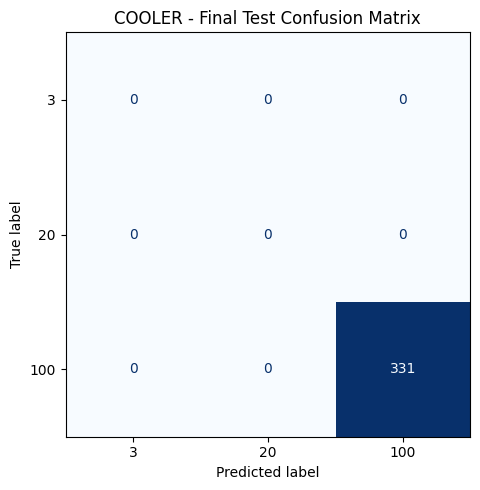


===== VALVE =====
Accuracy : 0.885196
Macro F1 : 0.880578


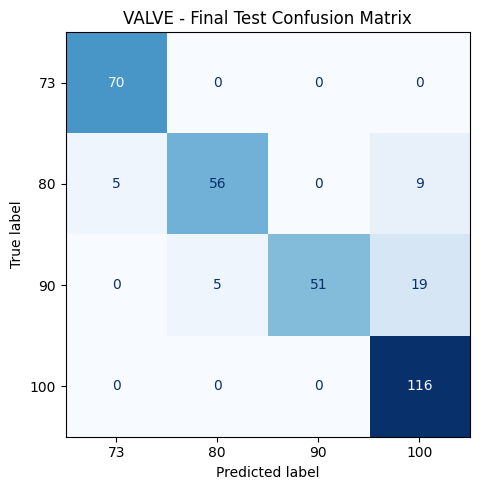


===== PUMP =====
Accuracy : 1.000000
Macro F1 : 1.000000


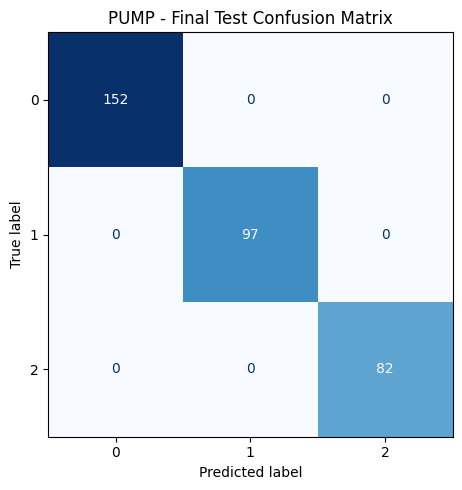


===== ACCUMULATOR =====
Accuracy : 0.232628
Macro F1 : 0.184175


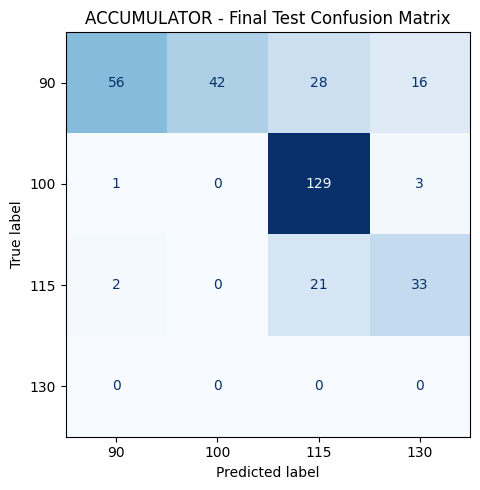


===== 최종 Test 성능 =====


,component,accuracy,macro_f1
0,cooler,1.000000,1.000000
1,valve,0.885196,0.880578
2,pump,1.000000,1.000000
3,accumulator,0.232628,0.184175


최종 Test 평균 Accuracy : 0.779456
최종 Test 평균 Macro F1 : 0.766188


In [25]:
# 최종 Test 데이터
test_df = (
    features_20s_compare[
        features_20s_compare["cycle_id"].between(1875, 2205)
    ]
    .sort_values("cycle_id")
)

X_test_final = test_df.drop(columns=["cycle_id"])

print("최종 Test 데이터 크기:", X_test_final.shape)


# 부품별 결과 저장
final_test_results = []


for component in component_order:

    # Test 정답
    y_test_final = (
        profile[
            profile["cycle_id"].between(1875, 2205)
        ]
        .sort_values("cycle_id")[component]
    )

    # 앞에서 만든 최종 모델
    model = final_models[component]

    # 예측
    y_pred_final = model.predict(X_test_final)

    # Accuracy
    accuracy = accuracy_score(
        y_test_final,
        y_pred_final
    )

    # Macro F1
    macro_f1 = f1_score(
        y_test_final,
        y_pred_final,
        average="macro"
    )

    final_test_results.append({
        "component": component,
        "accuracy": accuracy,
        "macro_f1": macro_f1
    })

    print(f"\n===== {component.upper()} =====")
    print(f"Accuracy : {accuracy:.6f}")
    print(f"Macro F1 : {macro_f1:.6f}")

    # 혼동행렬
    # Test에 특정 클래스가 없어도
    # 학습된 전체 클래스를 기준으로 표시
    labels = sorted(model.classes_)

    cm = confusion_matrix(
        y_test_final,
        y_pred_final,
        labels=labels
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )

    fig, ax = plt.subplots(figsize=(6, 5))

    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False
    )

    plt.title(
        f"{component.upper()} - Final Test Confusion Matrix"
    )

    plt.tight_layout()
    plt.show()


# 최종 성능표
final_test_results_df = pd.DataFrame(
    final_test_results
)

print("\n===== 최종 Test 성능 =====")

display(final_test_results_df)


print(
    "최종 Test 평균 Accuracy :",
    round(
        final_test_results_df["accuracy"].mean(),
        6
    )
)

print(
    "최종 Test 평균 Macro F1 :",
    round(
        final_test_results_df["macro_f1"].mean(),
        6
    )
)